# 4. Machine Learning Modeling Pipeline
### Objective

This notebook runs the full machine learning workflow used to predict startup success. It builds on the cleaned dataset from 02_data_cleaning_and_preprocessing.ipynb and uses helper functions from the src/ module.

**In this pipeline, we:**
- Load the cleaned dataset.
- Create and organize the features.
- Split the data over time (train/test).
- Build preprocessing + modeling pipelines (numeric & categorical).
- Train baseline models (Logistic Regression, Random Forest).
- Evaluate them with standard metrics and visualizations (ROC, PR, confusion matrix).
- Compare performance and save results.
- Outline the next steps based on the findings.


## 1. Imports & Configuration

In [1]:
import sys
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, brier_score_loss, roc_curve, precision_recall_curve,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = Path("..").resolve()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import data as data_mod
from src import features as features_mod
from src import split as split_mod
from src import model as model_mod
from src import evaluate as eval_mod

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Imports complete")
print(f"✓ Project root: {project_root}")

✓ Imports complete
✓ Project root: /Users/yusefbag/CascadeProjects/venturesurvive


## 2. Load Cleaned Dataset

We load the preprocessed dataset created in notebook 02. This dataset already contains:
- Filtered statuses (`acquired`, `ipo`, `closed`)
- Binary target `success`
- Cleaned funding amounts
- Converted date columns

In [2]:
clean_data_path = project_root / "data" / "processed" / "startups_clean.csv"

if not clean_data_path.exists():
    raise FileNotFoundError(f"Cleaned data not found at {clean_data_path}")

df_clean = pd.read_csv(clean_data_path)

df_clean = data_mod.convert_dates(df_clean)

print(f"Dataset loaded: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")
print(f"\nColumns: {list(df_clean.columns)}")

if 'success' in df_clean.columns:
    print("\n" + "="*60)
    print("Target distribution (success):")
    print("="*60)
    success_counts = df_clean['success'].value_counts().sort_index()
    success_pct = df_clean['success'].value_counts(normalize=True).sort_index() * 100
    
    summary_df = pd.DataFrame({
        'Count': success_counts,
        'Percentage': success_pct.round(2)
    })
    display(summary_df)
else:
    raise ValueError("Target column 'success' not found in cleaned dataset")

df_clean.head()


Dataset loaded: 13,334 rows × 15 columns

Columns: ['permalink', 'name', 'homepage_url', 'category_list', 'funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at', 'success']

Target distribution (success):


,Count,Percentage
success,,
0,6238,46.78
1,7096,53.22


,permalink,name,homepage_url,category_list,funding_total_usd,status,country_code,state_code,region,city,funding_rounds,founded_at,first_funding_at,last_funding_at,success
0,/organization/1-mainstream,1 Mainstream,http://www.1mainstream.com,Apps|Cable|Distribution|Software,5000000.0,acquired,USA,CA,SF Bay Area,Cupertino,1,2012-03-01,2015-03-17,2015-03-17,1
1,/organization/1000-markets,1000 Markets,http://www.1000markets.com,Art|E-Commerce|Marketplaces,500000.0,acquired,USA,WA,Seattle,Seattle,1,2009-01-01,2009-05-15,2009-05-15,1
2,/organization/1000memories,1000memories,http://1000memories.com,Curated Web,2535000.0,acquired,USA,CA,SF Bay Area,San Francisco,2,2010-07-01,2010-01-01,2011-02-16,1
3,/organization/100plus,100Plus,http://www.100plus.com,Analytics,1250000.0,acquired,USA,CA,SF Bay Area,San Francisco,2,2011-09-16,2011-11-02,2011-11-30,1
4,/organization/1010data,1010data,http://www.1010data.com,Software,35000000.0,acquired,USA,NY,New York City,New York,1,2000-01-01,2010-03-08,2010-03-08,1


## 3. Feature Assembly

We use `src.features.assemble_features()` to build the complete feature set, which includes:
- Time-based features (age at first funding, time between fundings)
- Geographic features (is_us, is_uk, is_eu, missingness flags)
- Category features (main category extraction)
- Log-transformed funding

In [3]:
df_features = features_mod.assemble_features(df_clean)

print(f"Features assembled: {df_features.shape}")
print(f"\nColumns after assembly: {list(df_features.columns)}")

if 'success' not in df_features.columns:
    raise ValueError("Target 'success' missing after feature assembly")

y = df_features['success'].astype(int)
X = df_features.drop(columns=["success", "status"])

numeric_cols = X.select_dtypes(include=['number']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("\n" + "="*60)
print(f"Numeric features ({len(numeric_cols)}):")
print("="*60)
for i, col in enumerate(numeric_cols, 1):
    print(f"  {i}. {col}")

print("\n" + "="*60)
print(f"Categorical features ({len(categorical_cols)}):")
print("="*60)
for i, col in enumerate(categorical_cols, 1):
    print(f"  {i}. {col}")

print(f"\nTotal features: {len(numeric_cols) + len(categorical_cols)}")
print(f"Target distribution:\n{y.value_counts().sort_index()}")

Features assembled: (13334, 30)

Columns after assembly: ['funding_total_usd', 'status', 'country_code', 'state_code', 'region', 'city', 'funding_rounds', 'founded_at', 'first_funding_at', 'last_funding_at', 'success', 'age_at_first_funding', 'time_between_first_last', 'is_us', 'is_uk', 'is_eu', 'country_code_missing', 'state_code_missing', 'region_missing', 'city_missing', 'category_main', 'log_funding_total', 'funding_per_round', 'log_funding_per_round', 'high_total_funding', 'high_funding_per_round', 'has_multiple_rounds', 'time_to_first_funding_years', 'company_age_at_last_funding_years', 'avg_round_interval_years']

Numeric features (13):
  1. funding_total_usd
  2. funding_rounds
  3. age_at_first_funding
  4. time_between_first_last
  5. log_funding_total
  6. funding_per_round
  7. log_funding_per_round
  8. high_total_funding
  9. high_funding_per_round
  10. has_multiple_rounds
  11. time_to_first_funding_years
  12. company_age_at_last_funding_years
  13. avg_round_interval_

## 4. Temporal Train/Test Split

We perform a temporal split to avoid data leakage and simulate real-world prediction scenarios:
- **Train**: startups with `first_funding_at < 2013-01-01`
- **Test**: startups with `first_funding_at >= 2013-01-01`

In [4]:
train_df, test_df = split_mod.temporal_split(
    df_features,
    cutoff_date="2013-01-01",
    date_col="first_funding_at"
)

print(f"Train set: {train_df.shape[0]:,} rows")
print(f"Test set:  {test_df.shape[0]:,} rows")
print(f"Split ratio: {train_df.shape[0]/df_features.shape[0]*100:.1f}% train / {test_df.shape[0]/df_features.shape[0]*100:.1f}% test")

y_train = train_df['success'].astype(int)
y_test = test_df['success'].astype(int)

X_train = train_df.drop(columns=['success'])
X_test = test_df.drop(columns=['success'])

print("\nTarget distribution in train set:")
print(y_train.value_counts(normalize=True).sort_index() * 100)

print("\nTarget distribution in test set:")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Train set: 10,688 rows
Test set:  2,646 rows
Split ratio: 80.2% train / 19.8% test

Target distribution in train set:
success
0    41.93488
1    58.06512
Name: proportion, dtype: float64

Target distribution in test set:
success
0    66.364324
1    33.635676
Name: proportion, dtype: float64


## 5. Preprocessing Pipeline

We build a scikit-learn `ColumnTransformer` to handle numeric and categorical features separately:

**Numeric pipeline:**
1. `SimpleImputer(strategy='median')` - handle missing values
2. `StandardScaler()` - normalize features

**Categorical pipeline:**
1. `SimpleImputer(strategy='most_frequent')` - handle missing values
2. `OneHotEncoder(handle_unknown='ignore')` - encode categories

In [5]:
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ],
    remainder='drop'
)

print("✓ Preprocessing pipeline created")
print(f"  - Numeric features: {len(numeric_cols)}")
print(f"  - Categorical features: {len(categorical_cols)}")

✓ Preprocessing pipeline created
  - Numeric features: 13
  - Categorical features: 5


## 6. Model Training & Evaluation

We train two baseline models and evaluate them comprehensively.

### 6.1 Logistic Regression Baseline

In [6]:
log_reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, n_jobs=-1))
])

print("Training Logistic Regression...")
log_reg_pipeline.fit(X_train, y_train)
print("✓ Training complete")

y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

lr_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_lr),
    'precision': precision_score(y_test, y_pred_lr, zero_division=0),
    'recall': recall_score(y_test, y_pred_lr, zero_division=0),
    'f1': f1_score(y_test, y_pred_lr, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob_lr),
    'brier': brier_score_loss(y_test, y_prob_lr)
}

print("\n" + "="*60)
print("LOGISTIC REGRESSION RESULTS")
print("="*60)
for metric, value in lr_metrics.items():
    print(f"{metric:12s}: {value:.4f}")

Training Logistic Regression...


✓ Training complete

LOGISTIC REGRESSION RESULTS
accuracy    : 0.7857
precision   : 0.6769
recall      : 0.6944
f1          : 0.6855
roc_auc     : 0.8557
brier       : 0.1464


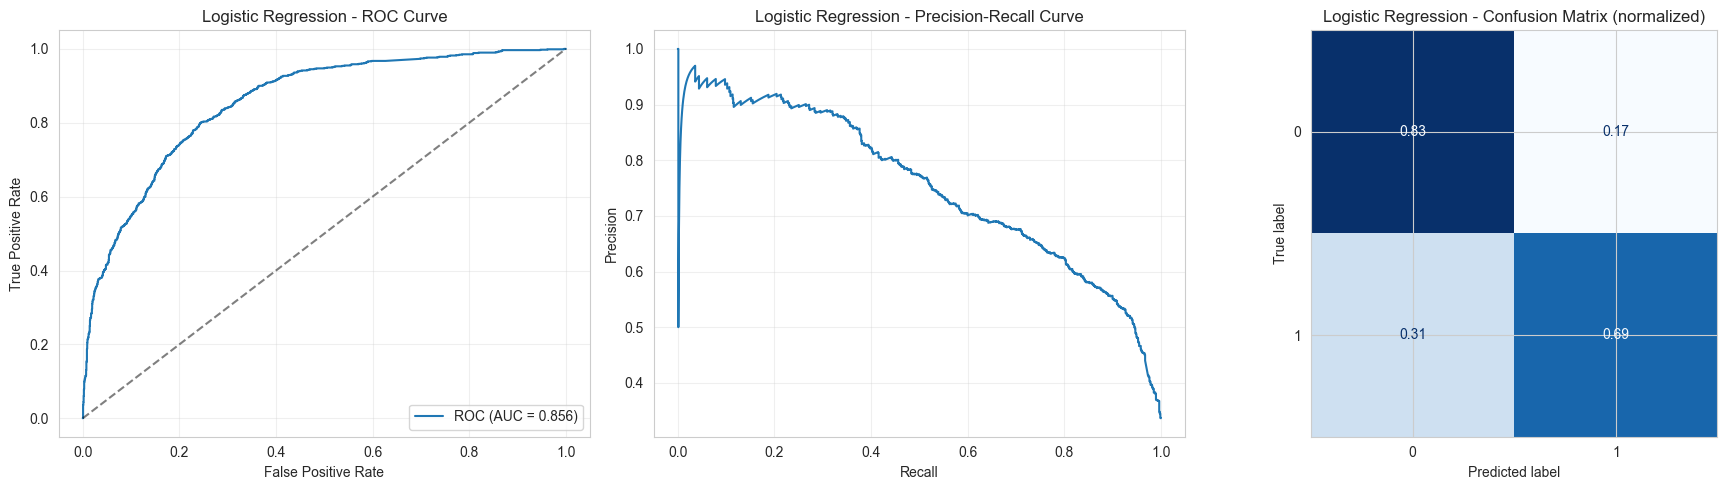

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
axes[0].plot(fpr_lr, tpr_lr, label=f"ROC (AUC = {lr_metrics['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Logistic Regression - ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_prob_lr)
axes[1].plot(recall_lr, precision_lr)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Logistic Regression - Precision-Recall Curve')
axes[1].grid(True, alpha=0.3)

cm_lr = confusion_matrix(y_test, y_pred_lr, normalize='true')
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=[0, 1])
disp_lr.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Logistic Regression - Confusion Matrix (normalized)')

plt.tight_layout()
plt.show()

### 6.2 Random Forest Baseline

In [8]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

print("Training Random Forest...")
rf_pipeline.fit(X_train, y_train)
print("✓ Training complete")

y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

rf_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_rf),
    'precision': precision_score(y_test, y_pred_rf, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf, zero_division=0),
    'f1': f1_score(y_test, y_pred_rf, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob_rf),
    'brier': brier_score_loss(y_test, y_prob_rf)
}

print("\n" + "="*60)
print("RANDOM FOREST RESULTS")
print("="*60)
for metric, value in rf_metrics.items():
    print(f"{metric:12s}: {value:.4f}")

Training Random Forest...
✓ Training complete

RANDOM FOREST RESULTS
accuracy    : 0.7668
precision   : 0.6375
recall      : 0.7112
f1          : 0.6723
roc_auc     : 0.8309
brier       : 0.1605


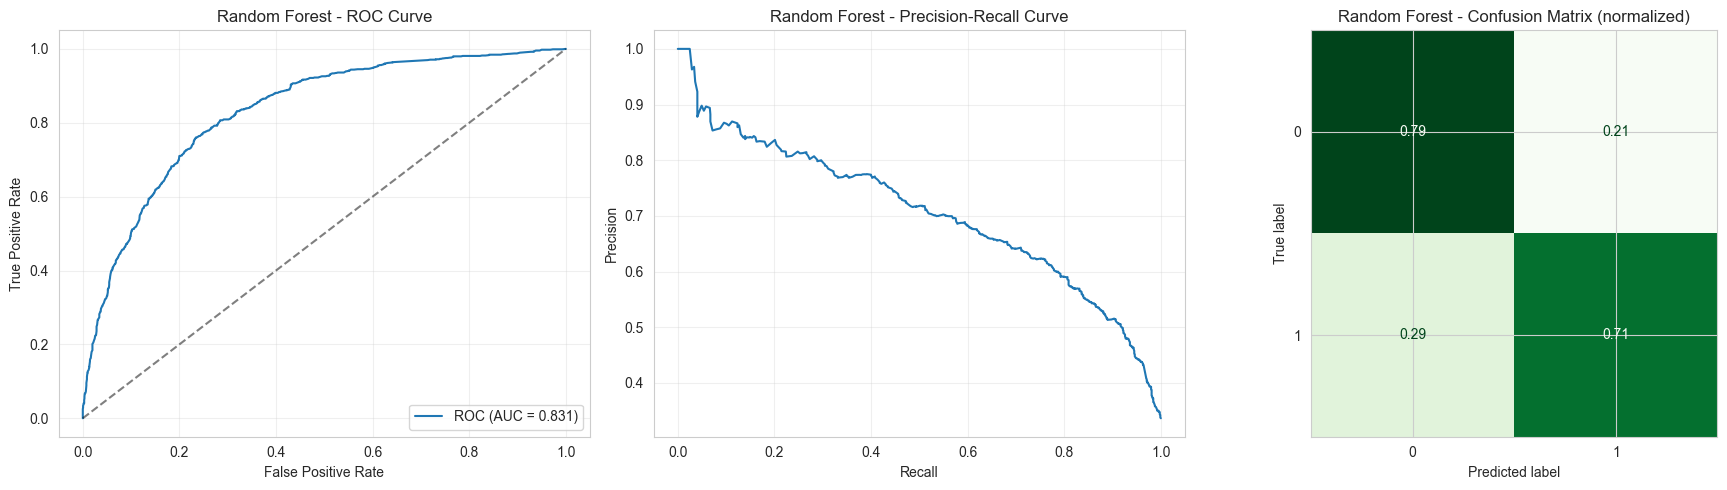

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
axes[0].plot(fpr_rf, tpr_rf, label=f"ROC (AUC = {rf_metrics['roc_auc']:.3f})")
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('Random Forest - ROC Curve')
axes[0].legend(loc='lower right')
axes[0].grid(True, alpha=0.3)

precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_prob_rf)
axes[1].plot(recall_rf, precision_rf)
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Random Forest - Precision-Recall Curve')
axes[1].grid(True, alpha=0.3)

cm_rf = confusion_matrix(y_test, y_pred_rf, normalize='true')
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[0, 1])
disp_rf.plot(ax=axes[2], cmap='Greens', colorbar=False)
axes[2].set_title('Random Forest - Confusion Matrix (normalized)')

plt.tight_layout()
plt.show()

## 7. Model Comparison

Comprehensive comparison of both baseline models.

In [10]:
comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [lr_metrics['accuracy'], rf_metrics['accuracy']],
    'ROC AUC': [lr_metrics['roc_auc'], rf_metrics['roc_auc']],
    'F1': [lr_metrics['f1'], rf_metrics['f1']],
    'Precision': [lr_metrics['precision'], rf_metrics['precision']],
    'Recall': [lr_metrics['recall'], rf_metrics['recall']],
    'Brier': [lr_metrics['brier'], rf_metrics['brier']]
})

comparison_df = comparison_df.round(4)

print("\n" + "="*80)
print("MODEL COMPARISON TABLE")
print("="*80)
display(comparison_df)

best_model = 'Logistic Regression' if lr_metrics['roc_auc'] > rf_metrics['roc_auc'] else 'Random Forest'
best_auc = max(lr_metrics['roc_auc'], rf_metrics['roc_auc'])

print(f"\n🏆 Best model by ROC AUC: {best_model} ({best_auc:.4f})")


MODEL COMPARISON TABLE


,Model,Accuracy,ROC AUC,F1,Precision,Recall,Brier
0,Logistic Regression,0.7857,0.8557,0.6855,0.6769,0.6944,0.1464
1,Random Forest,0.7668,0.8309,0.6723,0.6375,0.7112,0.1605



🏆 Best model by ROC AUC: Logistic Regression (0.8557)


## 8. Feature Importance Analysis

We use permutation importance to understand which features contribute most to model performance.

Computing permutation importance for Random Forest...

Top 15 most important features:


,feature,importance_mean,importance_std
19,category_main,0.034958,0.006971
5,city,0.003401,0.003038
6,funding_rounds,0.003023,0.000878
25,has_multiple_rounds,0.002910,0.000611
10,age_at_first_funding,0.001890,0.002432
27,company_age_at_last_funding_years,0.001587,0.002291
3,state_code,0.001550,0.002423
26,time_to_first_funding_years,0.001550,0.002010
28,avg_round_interval_years,0.001172,0.000853
11,time_between_first_last,0.000907,0.001111


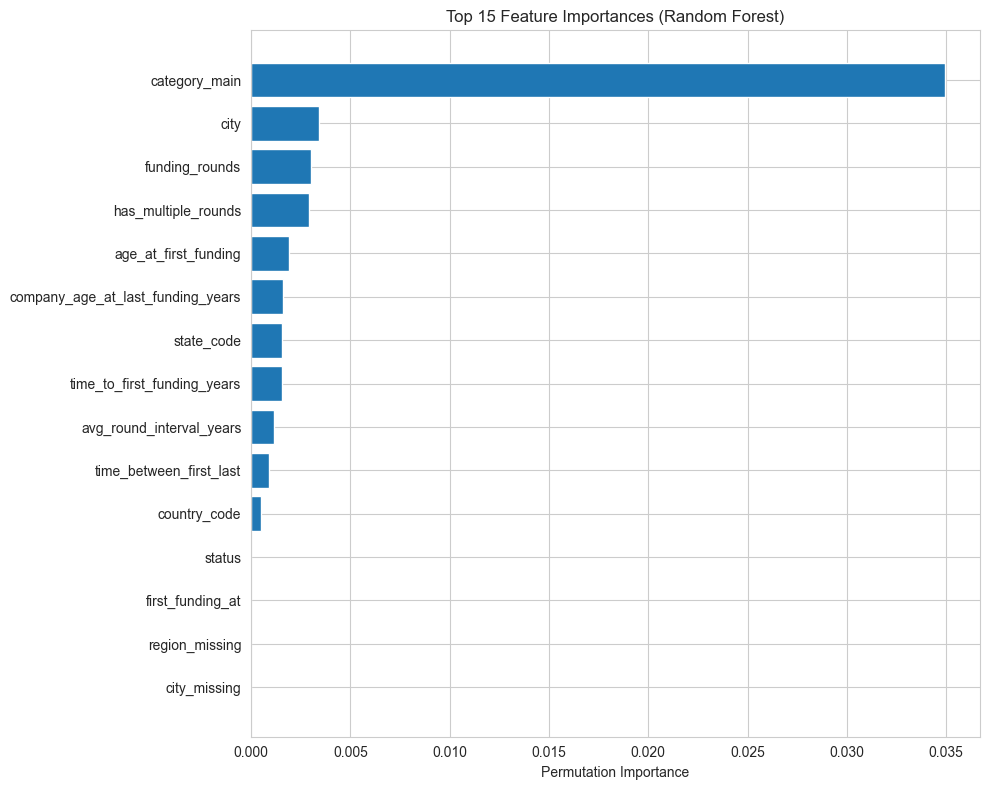

In [11]:
print("Computing permutation importance for Random Forest...")
perm_importance = permutation_importance(
    rf_pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

feature_names = X_test.columns

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std,
}).sort_values("importance_mean", ascending=False)

print("\nTop 15 most important features:")
display(importance_df.head(15))

plt.figure(figsize=(10, 8))
top_features = importance_df.head(15)
plt.barh(range(len(top_features)), top_features["importance_mean"])
plt.yticks(range(len(top_features)), top_features["feature"])
plt.xlabel("Permutation Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 9. Save Models

We save the complete pipelines (preprocessing + model) for future use.

In [12]:
models_dir = project_root / "models"
models_dir.mkdir(parents=True, exist_ok=True)

log_reg_path = models_dir / "log_reg_baseline.joblib"
rf_path = models_dir / "random_forest_baseline.joblib"

joblib.dump(log_reg_pipeline, log_reg_path)
joblib.dump(rf_pipeline, rf_path)

print("✓ Models saved successfully:")
print(f"  - Logistic Regression: {log_reg_path}")
print(f"  - Random Forest: {rf_path}")

✓ Models saved successfully:
  - Logistic Regression: /Users/yusefbag/CascadeProjects/venturesurvive/models/log_reg_baseline.joblib
  - Random Forest: /Users/yusefbag/CascadeProjects/venturesurvive/models/random_forest_baseline.joblib


## 10. Final Summary

Complete overview of the modeling pipeline and results.

In [13]:
print("="*80)
print("MODELING PIPELINE SUMMARY - VentureSurvive")
print("="*80)

print("\n### Dataset Information ###")
print(f"Total samples: {df_features.shape[0]:,}")
print(f"Train set: {train_df.shape[0]:,} ({train_df.shape[0]/df_features.shape[0]*100:.1f}%)")
print(f"Test set: {test_df.shape[0]:,} ({test_df.shape[0]/df_features.shape[0]*100:.1f}%)")
print(f"Temporal cutoff: 2013-01-01")

print("\n### Features ###")
print(f"Numeric features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print(f"Total features: {len(numeric_cols) + len(categorical_cols)}")

print("\n### Model Performance ###")
display(comparison_df)

print(f"\n🏆 Winner: {best_model}")
print(f"   ROC AUC: {best_auc:.4f}")

print("\n### Top 5 Most Important Features ###")
for i, row in importance_df.head(5).iterrows():
    print(f"  {row['feature']:30s} {row['importance_mean']:.4f} ± {row['importance_std']:.4f}")

print("\n### Artifacts Saved ###")
print(f"  ✓ {log_reg_path}")
print(f"  ✓ {rf_path}")

print("\n" + "="*80)

MODELING PIPELINE SUMMARY - VentureSurvive

### Dataset Information ###
Total samples: 13,334
Train set: 10,688 (80.2%)
Test set: 2,646 (19.8%)
Temporal cutoff: 2013-01-01

### Features ###
Numeric features: 13
Categorical features: 5
Total features: 18

### Model Performance ###


,Model,Accuracy,ROC AUC,F1,Precision,Recall,Brier
0,Logistic Regression,0.7857,0.8557,0.6855,0.6769,0.6944,0.1464
1,Random Forest,0.7668,0.8309,0.6723,0.6375,0.7112,0.1605



🏆 Winner: Logistic Regression
   ROC AUC: 0.8557

### Top 5 Most Important Features ###
  category_main                  0.0350 ± 0.0070
  city                           0.0034 ± 0.0030
  funding_rounds                 0.0030 ± 0.0009
  has_multiple_rounds            0.0029 ± 0.0006
  age_at_first_funding           0.0019 ± 0.0024

### Artifacts Saved ###
  ✓ /Users/yusefbag/CascadeProjects/venturesurvive/models/log_reg_baseline.joblib
  ✓ /Users/yusefbag/CascadeProjects/venturesurvive/models/random_forest_baseline.joblib



In [15]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Pipeline déjà créé : rf_pipeline (preprocessor + classifier)

# Paramètres à optimiser (uniquement ceux du classifier)
param_distributions = {
    "classifier__n_estimators": randint(200, 600),
    "classifier__max_depth": randint(4, 20),
    "classifier__min_samples_split": randint(2, 60),
    "classifier__min_samples_leaf": randint(1, 40),
    "classifier__max_features": uniform(0.3, 0.7),  # 0.3 à 1.0
    "classifier__class_weight": ["balanced", None],
}

tuner = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_distributions,
    n_iter=40,                  # assez pour trouver un bon optimum
    scoring="roc_auc",          # metric clé pour ton projet
    cv=3,                       # 3-fold for speed
    verbose=2,
    n_jobs=-1,
    random_state=42
)

print("🔍 Tuning Random Forest... (peut prendre 2-4 minutes)")
tuner.fit(X_train, y_train)

print("\n🏆 Best hyperparameters found:")
print(tuner.best_params_)

best_rf = tuner.best_estimator_

# Evaluate on test set
y_pred_rf_tuned = best_rf.predict(X_test)
y_prob_rf_tuned = best_rf.predict_proba(X_test)[:, 1]

rf_tuned_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_rf_tuned),
    'precision': precision_score(y_test, y_pred_rf_tuned, zero_division=0),
    'recall': recall_score(y_test, y_pred_rf_tuned, zero_division=0),
    'f1': f1_score(y_test, y_pred_rf_tuned, zero_division=0),
    'roc_auc': roc_auc_score(y_test, y_prob_rf_tuned),
    'brier': brier_score_loss(y_test, y_prob_rf_tuned)
}

print("\n📊 RANDOM FOREST (TUNED) RESULTS")
print("=================================")
for metric, value in rf_tuned_metrics.items():
    print(f"{metric:12s}: {value:.4f}")


🔍 Tuning Random Forest... (peut prendre 2-4 minutes)
Fitting 3 folds for each of 40 candidates, totalling 120 fits
[CV] END classifier__class_weight=None, classifier__max_depth=6, classifier__max_features=0.36998244107260203, classifier__min_samples_leaf=11, classifier__min_samples_split=25, classifier__n_estimators=572; total time= 6.5min
[CV] END classifier__class_weight=None, classifier__max_depth=6, classifier__max_features=0.36998244107260203, classifier__min_samples_leaf=11, classifier__min_samples_split=25, classifier__n_estimators=572; total time= 6.5min
[CV] END classifier__class_weight=None, classifier__max_depth=6, classifier__max_features=0.36998244107260203, classifier__min_samples_leaf=11, classifier__min_samples_split=25, classifier__n_estimators=572; total time= 6.6min
[CV] END classifier__class_weight=balanced, classifier__max_depth=7, classifier__max_features=0.9655000144869412, classifier__min_samples_leaf=8, classifier__min_samples_split=22, classifier__n_estimators

KeyboardInterrupt: 